# Notebook 18 — Empirical eventless counterfactual and weights

## Exercise 3: eventless background and empirical event-response ratios

Notebook 17 estimates an **event-unaware** background: target event days remain eligible OLS observations. Notebook 18 preserves the frozen equations, full chronology, and observed lagged states, but excludes targeted **age-0** event outcomes only from calibration targets. Event rows are never deleted or compressed.

The primary event universe, age-0 rule, overlap treatment, positivity rule, and pooling method are frozen before TEST event-response analysis.

**Conditional eventless clarification.** The eventless background is conditional on the actually observed history through t-1. Previous event-affected states therefore remain legitimate lagged predictors; it is not a recursively simulated history in which all past events have been erased. Only the contemporaneous event target is withheld from OLS.

## 1. Purpose and frozen upstream contract

The realised equation is $R_t=c_R+\beta_1R_{t-1}+\gamma_1I_{t-1}+u_t^R$. The implied equation is $I_t=c_I+\sum_{j=1}^{12}(\alpha_jQ_{t-j}+\beta_jR_{t-j}+\gamma_jI_{t-j})+u_t^I$. No GC, TDMI, BIC, lag selection, predictor change, or positivity transformation is performed here.

In [1]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from IPython.display import display

pd.set_option('display.max_columns', 100)
RUN_ID = pd.Timestamp.now(tz='UTC').isoformat()
PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'Data' / 'processed').exists())
PROCESSED = PROJECT_ROOT / 'Data' / 'processed'
INTERIM = PROJECT_ROOT / 'Data' / 'interim'
FIGURES = PROJECT_ROOT / 'figures'

def parse_bool(value):
    text = str(value).strip().lower()
    if text in {'true', '1'}: return True
    if text in {'false', '0'}: return False
    raise ValueError(f'Cannot parse boolean: {value!r}')

spec16 = pd.read_csv(PROCESSED / '16_primary_specification.csv').iloc[0]
spec17 = pd.read_csv(PROCESSED / '17_primary_specification.csv').iloc[0]
expected_contract = {'iv_specification': 'WEEKDAY_NORM_IV', 'iv_column': 'iv_model_var', 'selected_n': 1, 'selected_m': 12, 'retain_Q_to_R': False, 'retain_I_to_R': True, 'retain_Q_to_I': True, 'retain_R_to_I': True, 'event_unaware': True, 'eventless': False, 'equation_5_implemented': False}
for key, value in expected_contract.items():
    observed = parse_bool(spec16[key]) if isinstance(value, bool) else (int(spec16[key]) if isinstance(value, int) else str(spec16[key]))
    assert observed == value, f'Frozen Notebook 16 contract mismatch: {key}={observed!r}'
assert parse_bool(spec17['exercise_2_complete'])
assert spec17['primary_realised_model'] == 'R_PRIMARY_AR1_IV'
assert spec17['primary_implied_model'] == 'I_PRIMARY_FULL_12'
IV_COLUMN = str(spec16['iv_column'])
print(f'Frozen contract loaded: {IV_COLUMN}; n={int(spec16.selected_n)}, m={int(spec16.selected_m)}')

Frozen contract loaded: iv_model_var; n=1, m=12


## 2. Intact states and chronological lags

Lags are constructed from the full chronologically ordered canonical panel **before** event flags or masks are merged. The realised-equation base support retains Notebook 17's common-family $Q_{t-1}$ requirement even though it is not a retained realised predictor.

In [2]:
panel = pd.read_csv(PROCESSED / '16_empirical_analysis_panel.csv', parse_dates=['model_day']).sort_values('model_day').reset_index(drop=True)
required = {'model_day', 'sample_split', 'squared_return', 'realised_variance_ann_252', IV_COLUMN}
assert required.issubset(panel.columns)
panel['Q'] = pd.to_numeric(panel['squared_return'], errors='coerce')
panel['R'] = pd.to_numeric(panel['realised_variance_ann_252'], errors='coerce')
panel['I'] = pd.to_numeric(panel[IV_COLUMN], errors='coerce')
model_day_unique = panel['model_day'].is_unique
model_day_monotonic = panel['model_day'].is_monotonic_increasing
assert model_day_unique and model_day_monotonic
for state in ['Q', 'R', 'I']:
    for lag in range(1, 13):
        panel[f'{state}_lag{lag}'] = panel[state].shift(lag)
lag_columns = [f'{state}_lag{lag}' for state in ['Q', 'R', 'I'] for lag in range(1, 13)]
lag_snapshot = panel[['model_day', *lag_columns]].copy()
R_FEATURES = ['R_lag1', 'I_lag1']
I_FEATURES = [f'{state}_lag{lag}' for state in ['Q', 'R', 'I'] for lag in range(1, 13)]
BASE_COLUMNS = {'R': ['R', 'Q_lag1', 'R_lag1', 'I_lag1'], 'I': ['I', *I_FEATURES]}
for target in ['R', 'I']:
    panel[f'{target}_base_eligible'] = np.isfinite(panel[BASE_COLUMNS[target]]).all(axis=1)
base_counts = panel.groupby('sample_split')[['R_base_eligible', 'I_base_eligible']].sum().astype(int)
assert tuple(base_counts.loc['train']) == (3005, 2226)
assert tuple(base_counts.loc['validation']) == (1181, 1087)
display(base_counts)

,R_base_eligible,I_base_eligible
sample_split,,
test,1182,1071
train,3005,2226
validation,1181,1087


## 3. Frozen six-family event construction and explicit sessions

Raw Bloomberg labels are mapped by an explicit dictionary and components are collapsed to release family × model day. The model day D is the actual existing interval [D-1 17:00 New York, D 17:00 New York). Naive **17:00 wall-clock** endpoints are constructed first and then localised, so DST is handled correctly.

In [3]:
FAMILY_LABELS = {'FOMC': ['FOMC Rate Decision (Upper Bound)'], 'US Employment': ['Change in Nonfarm Payrolls', 'Unemployment Rate'], 'US CPI': ['CPI MoM', 'CPI YoY'], 'BoJ': ['BOJ Target Rate'], 'JPY National CPI': ['Natl CPI YoY'], 'JPY GDP': ['GDP SA QoQ', 'GDP Annualized SA QoQ', 'GDP Deflator YoY']}
label_to_family = {label: family for family, labels in FAMILY_LABELS.items() for label in labels}
event_family_mapping = pd.DataFrame([(label, family) for label, family in label_to_family.items()], columns=['raw_event_label', 'mapped_family'])
raw_events = pd.read_csv(INTERIM / 'g10_usd_jpy_events_audited.csv')
raw_events = raw_events.loc[raw_events['event'].isin(label_to_family)].copy().reset_index(names='raw_event_id')
raw_events['raw_event_label'] = raw_events['event']
raw_events['mapped_family'] = raw_events['event'].map(label_to_family)
raw_events['event_datetime_utc'] = pd.to_datetime(raw_events['event_datetime_utc'], utc=True, errors='coerce', format='mixed')
raw_events['event_datetime_ny'] = raw_events['event_datetime_utc'].dt.tz_convert('America/New_York')

sessions = pd.DataFrame({'model_day': panel['model_day']})
sessions['session_open_naive'] = sessions['model_day'] - pd.Timedelta(days=1) + pd.Timedelta(hours=17)
sessions['session_close_naive'] = sessions['model_day'] + pd.Timedelta(hours=17)
sessions['session_open_ny'] = sessions['session_open_naive'].dt.tz_localize('America/New_York')
sessions['session_close_ny'] = sessions['session_close_naive'].dt.tz_localize('America/New_York')
sessions['session_open_utc'] = sessions['session_open_ny'].dt.tz_convert('UTC')
sessions['session_close_utc'] = sessions['session_close_ny'].dt.tz_convert('UTC')
assert sessions['session_open_ny'].dt.hour.eq(17).all() and sessions['session_close_ny'].dt.hour.eq(17).all()

valid_events = raw_events.loc[raw_events['event_datetime_utc'].notna()].sort_values('event_datetime_utc').copy()
probed = pd.merge_asof(valid_events, sessions[['model_day', 'session_open_utc', 'session_close_utc']].sort_values('session_open_utc'), left_on='event_datetime_utc', right_on='session_open_utc', direction='backward')
probed['explicit_member'] = probed['session_open_utc'].le(probed['event_datetime_utc']) & probed['event_datetime_utc'].lt(probed['session_close_utc'])
probed['mapped_model_day'] = probed['model_day'].where(probed['explicit_member'])
panel_start, panel_end = sessions['session_open_utc'].min(), sessions['session_close_utc'].max()
probed['mapping_status'] = np.select([probed['explicit_member'], ~probed['event_datetime_utc'].between(panel_start, panel_end, inclusive='both')], ['MAPPED', 'OUTSIDE_EMPIRICAL_PANEL'], default='NO_EXISTING_SESSION_INTERVAL')
mapping_audit = raw_events[['raw_event_id', 'raw_event_label', 'mapped_family', 'event_datetime_utc', 'event_datetime_ny']].merge(probed[['raw_event_id', 'mapped_model_day', 'mapping_status', 'explicit_member']], on='raw_event_id', how='left')
mapping_audit['mapping_status'] = mapping_audit['mapping_status'].fillna('INVALID_TIMESTAMP')
mapping_audit['explicit_member'] = mapping_audit['explicit_member'].eq(True)
mapping_audit['mapped_model_day'] = pd.to_datetime(mapping_audit['mapped_model_day'])
display(mapping_audit['mapping_status'].value_counts().rename_axis('mapping_status').to_frame('raw_rows'))
uncontained_event_audit = mapping_audit.loc[mapping_audit['mapping_status'].eq('NO_EXISTING_SESSION_INTERVAL'), ['mapped_family', 'raw_event_label', 'event_datetime_utc', 'event_datetime_ny', 'mapping_status']]
display(uncontained_event_audit)

,raw_rows
mapping_status,
MAPPED,2315
OUTSIDE_EMPIRICAL_PANEL,310
NO_EXISTING_SESSION_INTERVAL,1


,mapped_family,raw_event_label,event_datetime_utc,event_datetime_ny,mapping_status
438,JPY National CPI,Natl CPI YoY,2005-02-25 23:30:00+00:00,2005-02-25 18:30:00-05:00,NO_EXISTING_SESSION_INTERVAL


The displayed event is intentionally not force-mapped to a nearby observed model day because no explicit model-day session interval contains its timestamp.

In [4]:
modelled_raw = mapping_audit.loc[mapping_audit['mapping_status'].eq('MAPPED')].copy()
all_modelled_event_occurrences_have_valid_mapping = bool(modelled_raw['explicit_member'].all() and modelled_raw['event_datetime_utc'].notna().all())
assert all_modelled_event_occurrences_have_valid_mapping
occurrences = (modelled_raw.groupby(['mapped_family', 'mapped_model_day'], as_index=False).agg(raw_row_count=('raw_event_id', 'size'), raw_labels=('raw_event_label', lambda x: ' | '.join(sorted(set(x)))), n_unique_raw_timestamps=('event_datetime_utc', 'nunique'), first_event_time_utc=('event_datetime_utc', 'min'), last_event_time_utc=('event_datetime_utc', 'max')).rename(columns={'mapped_family': 'family', 'mapped_model_day': 'model_day'}))
occurrences['release_span_seconds'] = (occurrences['last_event_time_utc'] - occurrences['first_event_time_utc']).dt.total_seconds()
occurrences = occurrences.merge(panel[['model_day', 'sample_split']], on='model_day', how='left', validate='many_to_one')
assert not occurrences.duplicated(['family', 'model_day']).any()

day_flags = occurrences.groupby('model_day', as_index=False).agg(n_target_families=('family', 'nunique'), family_set=('family', lambda x: ' | '.join(sorted(x))))
day_flags['is_target_event_day'] = day_flags['n_target_families'].ge(1)
day_flags['is_clean_single_family'] = day_flags['n_target_families'].eq(1)
day_flags['is_overlap'] = day_flags['n_target_families'].gt(1)
event_day_flags = panel[['model_day']].merge(day_flags, on='model_day', how='left')
event_day_flags['n_target_families'] = event_day_flags['n_target_families'].fillna(0).astype(int)
event_day_flags['family_set'] = event_day_flags['family_set'].fillna('')
for col in ['is_target_event_day', 'is_clean_single_family', 'is_overlap']:
    event_day_flags[col] = event_day_flags[col].eq(True)
row_count_before_merge = len(panel)
panel = panel.merge(event_day_flags, on='model_day', how='left', validate='one_to_one')
lags_preserved_after_event_merge = len(panel) == row_count_before_merge and panel[['model_day', *lag_columns]].equals(lag_snapshot)
assert lags_preserved_after_event_merge
occurrences = occurrences.merge(panel[['model_day', 'n_target_families', 'family_set', 'is_clean_single_family', 'is_overlap', 'R_base_eligible', 'I_base_eligible']], on='model_day', how='left', validate='many_to_one')

## 4. PRE-TEST audit and age-0 eventless masks

Every overlap day is withheld once from calibration; all associated family labels remain in the occurrence-level export. The following checks reproduce the agreed PRE-TEST support without inspecting TEST event-response results.

In [5]:
support = occurrences.groupby(['family', 'sample_split']).size().unstack(fill_value=0).reindex(index=list(FAMILY_LABELS), columns=['train', 'validation'], fill_value=0)
expected_support = {'FOMC': (114, 38), 'US Employment': (166, 56), 'US CPI': (167, 56), 'BoJ': (146, 38), 'JPY National CPI': (165, 56), 'JPY GDP': (99, 37)}
for family, expected in expected_support.items(): assert tuple(support.loc[family]) == expected, f'Family support mismatch: {family}'
for split, union_count, overlap_count in [('train', 803, 53), ('validation', 264, 17)]:
    subset = panel.loc[panel['sample_split'].eq(split)]
    assert int(subset['is_target_event_day'].sum()) == union_count
    assert int(subset['is_overlap'].sum()) == overlap_count
for target in ['R', 'I']:
    panel[f'{target}_eventless_eligible'] = panel[f'{target}_base_eligible'] & ~panel['is_target_event_day']
assert tuple(panel.loc[panel['sample_split'].eq('train'), ['R_eventless_eligible', 'I_eventless_eligible']].sum()) == (2321, 1704)
assert tuple(panel.loc[panel['sample_split'].eq('validation'), ['R_eventless_eligible', 'I_eventless_eligible']].sum()) == (919, 843)

table_18_1 = pd.DataFrame({'family': list(FAMILY_LABELS), 'raw_labels': [' | '.join(FAMILY_LABELS[f]) for f in FAMILY_LABELS]})
for split, prefix in [('train', 'TRAIN'), ('validation', 'VALIDATION')]:
    q = occurrences.loc[occurrences['sample_split'].eq(split)].groupby('family').agg(event_days=('model_day', 'size'), R_eligible=('R_base_eligible', 'sum'), I_eligible=('I_base_eligible', 'sum')).reindex(list(FAMILY_LABELS), fill_value=0)
    table_18_1[f'{prefix} event days'] = q['event_days'].to_numpy()
    table_18_1[f'{prefix} R-eligible event days'] = q['R_eligible'].to_numpy()
    table_18_1[f'{prefix} I-eligible event days'] = q['I_eligible'].to_numpy()
print('Table 18.1 — Frozen event families and PRE-TEST support')
display(table_18_1)

Table 18.1 — Frozen event families and PRE-TEST support


,family,raw_labels,TRAIN event days,TRAIN R-eligible event days,TRAIN I-eligible event days,VALIDATION event days,VALIDATION R-eligible event days,VALIDATION I-eligible event days
0,FOMC,FOMC Rate Decision (Upper Bound),114,96,78,38,38,36
1,US Employment,Change in Nonfarm Payrolls | Unemployment Rate,166,137,101,56,55,50
2,US CPI,CPI MoM | CPI YoY,167,149,99,56,56,47
3,BoJ,BOJ Target Rate,146,131,115,38,38,38
4,JPY National CPI,Natl CPI YoY,165,138,112,56,55,55
5,JPY GDP,GDP SA QoQ | GDP Annualized SA QoQ | GDP Defla...,99,84,62,37,37,33


In [6]:
support_rows = []
for stage, splits in [('TRAIN', ['train']), ('TRAIN_PLUS_VALIDATION', ['train', 'validation'])]:
    for target in ['R', 'I']:
        base_n = int((panel['sample_split'].isin(splits) & panel[f'{target}_base_eligible']).sum())
        removed_n = int((panel['sample_split'].isin(splits) & panel[f'{target}_base_eligible'] & panel['is_target_event_day']).sum())
        support_rows.append({'stage': stage, 'target': target, 'base_eligible_N': base_n, 'eligible_target_event_N_removed': removed_n, 'eventless_calibration_N': base_n - removed_n, 'fraction_retained': (base_n - removed_n) / base_n})
table_18_2 = pd.DataFrame(support_rows)
assert tuple(table_18_2.loc[table_18_2['stage'].eq('TRAIN'), 'eventless_calibration_N']) == (2321, 1704)
assert tuple(table_18_2.loc[table_18_2['stage'].eq('TRAIN_PLUS_VALIDATION'), 'eventless_calibration_N']) == (3240, 2547)
print('Table 18.2 — Eventless calibration support')
display(table_18_2)

Table 18.2 — Eventless calibration support


,stage,target,base_eligible_N,eligible_target_event_N_removed,eventless_calibration_N,fraction_retained
0,TRAIN,R,3005,684,2321,0.772379
1,TRAIN,I,2226,522,1704,0.765499
2,TRAIN_PLUS_VALIDATION,R,4186,946,3240,0.774009
3,TRAIN_PLUS_VALIDATION,I,3313,766,2547,0.768790


## 5. TRAIN eventless calibration

Exactly two frozen-structure OLS models are fitted on TRAIN eventless targets. Coefficients, conventional residual standard error, and Gaussian residual-scale MLE are retained.

In [7]:
def fit_eventless(target, splits, calibration_stage):
    features = R_FEATURES if target == 'R' else I_FEATURES
    sample = panel.loc[panel['sample_split'].isin(splits) & panel[f'{target}_eventless_eligible']].copy()
    fit = sm.OLS(sample[target], sm.add_constant(sample[features], has_constant='add')).fit()
    return {'target': target, 'features': features, 'sample': sample, 'fit': fit, 'calibration_stage': calibration_stage}

def coefficient_rows(model):
    fit = model['fit']; ci = fit.conf_int()
    out = pd.DataFrame({'predictor': fit.params.index, 'coefficient': fit.params.values, 'std_error': fit.bse.values, 'ci_lower': ci.iloc[:, 0].values, 'ci_upper': ci.iloc[:, 1].values})
    out['target'] = model['target']; out['model'] = 'R_EVENTLESS_PRIMARY' if model['target'] == 'R' else 'I_EVENTLESS_PRIMARY'
    out['calibration_stage'] = model['calibration_stage']; out['calibration_N'] = len(model['sample'])
    out['coefficient_block'] = out['predictor'].map(lambda p: 'intercept' if p == 'const' else p[0])
    out['lag'] = pd.to_numeric(out['predictor'].str.extract(r'lag(\d+)')[0], errors='coerce')
    return out

def residual_scale_row(model):
    fit = model['fit']; ssr = float(np.sum(fit.resid ** 2)); nobs = int(fit.nobs)
    return {'record_type': 'residual_scale', 'target': model['target'], 'calibration_stage': model['calibration_stage'], 'N': nobs, 'SSR': ssr, 'residual_standard_error_conventional': math.sqrt(fit.mse_resid), 'residual_scale_mle': math.sqrt(ssr / nobs)}

train_models = {target: fit_eventless(target, ['train'], 'TRAIN') for target in ['R', 'I']}
train_coefficients = pd.concat([coefficient_rows(model) for model in train_models.values()], ignore_index=True)
assert len(train_models['R']['sample']) == 2321 and len(train_models['I']['sample']) == 1704
display(train_coefficients)

,predictor,coefficient,std_error,ci_lower,ci_upper,target,model,calibration_stage,calibration_N,coefficient_block,lag
0,const,0.003401,0.000401,0.002615,0.004186,R,R_EVENTLESS_PRIMARY,TRAIN,2321,intercept,NaN
1,R_lag1,0.120102,0.019788,0.081298,0.158906,R,R_EVENTLESS_PRIMARY,TRAIN,2321,R,1.0
2,I_lag1,0.354282,0.016386,0.322149,0.386414,R,R_EVENTLESS_PRIMARY,TRAIN,2321,I,1.0
3,const,-0.000379,0.000566,-0.001489,0.000731,I,I_EVENTLESS_PRIMARY,TRAIN,1704,intercept,NaN
4,Q_lag1,-4.611876,5.260061,-14.928896,5.705144,I,I_EVENTLESS_PRIMARY,TRAIN,1704,Q,1.0
5,Q_lag2,-6.044180,4.723393,-15.308586,3.220226,I,I_EVENTLESS_PRIMARY,TRAIN,1704,Q,2.0
6,Q_lag3,0.893899,5.359971,-9.619083,11.406882,I,I_EVENTLESS_PRIMARY,TRAIN,1704,Q,3.0
7,Q_lag4,24.872298,4.950284,15.162869,34.581726,I,I_EVENTLESS_PRIMARY,TRAIN,1704,Q,4.0
8,Q_lag5,-10.509533,5.646042,-21.583612,0.564545,I,I_EVENTLESS_PRIMARY,TRAIN,1704,Q,5.0
9,Q_lag6,-6.888206,5.876737,-18.414767,4.638355,I,I_EVENTLESS_PRIMARY,TRAIN,1704,Q,6.0


## 6. VALIDATION assessment

TRAIN eventless coefficients forecast every base-eligible VALIDATION date, including event dates. Notebook 17 and Notebook 18 are compared only on exactly aligned ordinary VALIDATION dates; this is diagnostic and does not reopen model selection.

In [8]:
def forecast_model(model, split, forecast_stage):
    target, features, fit = model['target'], model['features'], model['fit']
    rows = panel.loc[panel['sample_split'].eq(split) & panel[f'{target}_base_eligible']].copy()
    rows['background_forecast'] = fit.predict(sm.add_constant(rows[features], has_constant='add'))
    rows['actual'] = rows[target]; rows['target'] = target; rows['forecast_stage'] = forecast_stage
    return rows[['model_day', 'sample_split', 'forecast_stage', 'target', 'actual', 'background_forecast', 'is_target_event_day', 'n_target_families', 'family_set', 'is_clean_single_family', 'is_overlap']]

def forecast_metrics(frame):
    error = frame['actual'] - frame['background_forecast']; qmask = frame['actual'].gt(0) & frame['background_forecast'].gt(0)
    qlike = (frame.loc[qmask, 'actual'] / frame.loc[qmask, 'background_forecast'] - np.log(frame.loc[qmask, 'actual'] / frame.loc[qmask, 'background_forecast']) - 1)
    return {'N': len(frame), 'MAE': float(np.abs(error).mean()), 'RMSE': float(np.sqrt(np.mean(error ** 2))), 'mean_error': float(error.mean()), 'positive_fraction': float(frame['background_forecast'].gt(0).mean()), 'positive_only_QLIKE': float(qlike.mean()) if len(qlike) else np.nan, 'QLIKE_valid_N': int(qmask.sum())}

validation_forecasts = pd.concat([forecast_model(train_models[t], 'validation', 'validation_oos_background') for t in ['R', 'I']], ignore_index=True)
old_forecasts = pd.read_csv(PROCESSED / '17_forecasts_validation.csv', parse_dates=['model_day'])
old_forecasts = old_forecasts.loc[((old_forecasts['target'].eq('R')) & old_forecasts['model'].eq('R_PRIMARY_AR1_IV')) | ((old_forecasts['target'].eq('I')) & old_forecasts['model'].eq('I_PRIMARY_FULL_12')), ['model_day', 'target', 'actual', 'raw_forecast']].rename(columns={'raw_forecast': 'background_forecast'})
comparison_rows = []
for target in ['R', 'I']:
    new = validation_forecasts.loc[(validation_forecasts['target'].eq(target)) & ~validation_forecasts['is_target_event_day']].copy()
    old = old_forecasts.loc[old_forecasts['target'].eq(target)].copy()
    aligned = new[['model_day', 'target', 'actual', 'background_forecast']].merge(old, on=['model_day', 'target', 'actual'], suffixes=('_eventless', '_event_unaware'), validate='one_to_one')
    for label, col in [('Notebook17_event_unaware', 'background_forecast_event_unaware'), ('Notebook18_eventless', 'background_forecast_eventless')]:
        result = forecast_metrics(aligned[['actual', col]].rename(columns={col: 'background_forecast'}))
        result.update({'target': target, 'background_type': label}); comparison_rows.append(result)
table_18_3 = pd.DataFrame(comparison_rows)[['target', 'background_type', 'N', 'MAE', 'RMSE', 'mean_error', 'positive_fraction', 'positive_only_QLIKE', 'QLIKE_valid_N']]
print('Table 18.3 — VALIDATION ordinary-background comparison')
display(table_18_3)

Table 18.3 — VALIDATION ordinary-background comparison


,target,background_type,N,MAE,RMSE,mean_error,positive_fraction,positive_only_QLIKE,QLIKE_valid_N
0,R,Notebook17_event_unaware,919,0.003145,0.005916,-0.001772,1.000000,0.321859,919
1,R,Notebook18_eventless,919,0.002992,0.005881,-0.001527,1.000000,0.308184,919
2,I,Notebook17_event_unaware,843,0.002148,0.004796,-0.000094,0.994069,0.173951,838
3,I,Notebook18_eventless,843,0.002343,0.005217,0.000237,0.986951,0.750263,832


## 7. Coefficient stability (descriptive)

The comparison uses Notebook 17 TRAIN-stage coefficients. The implied Q, R and I lag blocks are reported separately because their scales differ; no aggregate 36-coefficient stability statistic is calculated.

In [9]:
old_coefficients = pd.read_csv(PROCESSED / '17_coefficients_validation.csv')
old_R = old_coefficients.loc[old_coefficients['model'].eq('R_PRIMARY_AR1_IV'), ['predictor', 'coefficient']].rename(columns={'coefficient': 'old'})
new_R = train_coefficients.loc[train_coefficients['target'].eq('R'), ['predictor', 'coefficient']].rename(columns={'coefficient': 'eventless'})
realised_stability = old_R.merge(new_R, on='predictor', validate='one_to_one')
realised_stability['difference'] = realised_stability['eventless'] - realised_stability['old']
old_I = old_coefficients.loc[old_coefficients['model'].eq('I_PRIMARY_FULL_12'), ['predictor', 'coefficient']].rename(columns={'coefficient': 'old'})
new_I = train_coefficients.loc[train_coefficients['target'].eq('I'), ['predictor', 'coefficient']].rename(columns={'coefficient': 'eventless'})
implied_stability_detail = old_I.merge(new_I, on='predictor', validate='one_to_one')
implied_stability_detail['difference'] = implied_stability_detail['eventless'] - implied_stability_detail['old']
block_rows = []
for block in ['Q', 'R', 'I']:
    block_data = implied_stability_detail.loc[implied_stability_detail['predictor'].str.startswith(f'{block}_')].copy()
    block_rows.append({'block': block, 'correlation_old_eventless': block_data['old'].corr(block_data['eventless']), 'L2_norm_change': np.linalg.norm(block_data['difference']), 'maximum_absolute_change': block_data['difference'].abs().max()})
block_stability = pd.DataFrame(block_rows)
table_18_4_lags = pd.DataFrame({'lag': range(1, 13)})
for block in ['Q', 'R', 'I']:
    q = implied_stability_detail.loc[implied_stability_detail['predictor'].str.startswith(f'{block}_')].copy()
    q['lag'] = q['predictor'].str.extract(r'lag(\d+)').astype(int)
    table_18_4_lags = table_18_4_lags.merge(q[['lag', 'old', 'eventless']].rename(columns={'old': f'{block}_old', 'eventless': f'{block}_eventless'}), on='lag', validate='one_to_one')
print('Table 18.4 — parameter stability')
display(realised_stability)
display(implied_stability_detail.loc[implied_stability_detail['predictor'].eq('const')])
display(block_stability)
display(table_18_4_lags)

Table 18.4 — parameter stability


,predictor,old,eventless,difference
0,const,0.003530,0.003401,-0.000130
1,R_lag1,0.111386,0.120102,0.008716
2,I_lag1,0.383168,0.354282,-0.028887


,predictor,old,eventless,difference
0,const,0.000051,-0.000379,-0.00043


,block,correlation_old_eventless,L2_norm_change,maximum_absolute_change
0,Q,0.929364,17.782454,9.841644
1,R,0.965593,0.055787,0.035074
2,I,0.991376,0.147493,0.066899


,lag,Q_old,Q_eventless,R_old,R_eventless,I_old,I_eventless
0,1,-4.876813,-4.611876,0.125059,0.089985,0.393732,0.412420
1,2,3.797463,-6.044180,0.018965,0.019204,0.196075,0.262974
2,3,1.282548,0.893899,-0.047936,-0.076807,-0.023935,-0.043884
3,4,20.665618,24.872298,-0.057216,-0.042777,0.045670,0.095114
4,5,-6.066378,-10.509533,0.034643,0.044278,-0.142010,-0.160007
5,6,-14.106726,-6.888206,0.026461,0.019070,0.013209,0.010937
6,7,3.869336,7.729946,0.007455,0.015669,0.023313,-0.042479
7,8,9.260110,7.635818,-0.029049,-0.045120,0.047761,0.050694
8,9,-6.565448,-11.134565,-0.058174,-0.057940,-0.029690,-0.013553
9,10,-23.002701,-32.268838,-0.064473,-0.068919,0.375015,0.429044


In [10]:
# Descriptive TRAIN residual-scale comparison; it does not alter the frozen specification.
event_unaware_scales = pd.read_csv(PROCESSED / '17_residual_scales.csv')
event_unaware_scales = event_unaware_scales.loc[((event_unaware_scales['target'].eq('R')) & event_unaware_scales['model'].eq('R_PRIMARY_AR1_IV')) | ((event_unaware_scales['target'].eq('I')) & event_unaware_scales['model'].eq('I_PRIMARY_FULL_12'))]
event_unaware_scales = event_unaware_scales.loc[event_unaware_scales['calibration_split'].eq('train'), ['target', 'residual_scale_mle']].rename(columns={'residual_scale_mle': 'event_unaware_sigma_mle'})
eventless_scales = pd.DataFrame([residual_scale_row(train_models[target]) for target in ['R', 'I']])[['target', 'residual_scale_mle']].rename(columns={'residual_scale_mle': 'eventless_sigma_mle'})
residual_scale_stability = event_unaware_scales.merge(eventless_scales, on='target', validate='one_to_one')
residual_scale_stability['difference'] = residual_scale_stability['eventless_sigma_mle'] - residual_scale_stability['event_unaware_sigma_mle']
residual_scale_stability['relative_change'] = residual_scale_stability['difference'] / residual_scale_stability['event_unaware_sigma_mle']
print('Descriptive TRAIN residual-scale MLE stability')
display(residual_scale_stability)


Descriptive TRAIN residual-scale MLE stability


,target,event_unaware_sigma_mle,eventless_sigma_mle,difference,relative_change
0,R,0.016468,0.015822,-0.000646,-0.039199
1,I,0.014688,0.015207,0.000519,0.035326


## 8. PRE-TEST EXERCISE 3 DESIGN FREEZE

TEST event responses were not used to select the Exercise 3 event universe, masking rule, overlap treatment, positivity rule, or pooling method. TEST had already been evaluated for ordinary-background forecasting in Notebook 17; it is not described as globally untouched.

In [11]:
design_freeze = {'primary_event_universe': 'FOMC | US Employment | US CPI | BoJ | JPY National CPI | JPY GDP', 'event_source': 'g10_usd_jpy_events_audited.csv', 'component_collapsing_rule': 'raw Bloomberg labels collapsed to family x model day', 'model_day_timezone': 'America/New_York', 'model_day_interval_rule': '[D-1 17:00 NY, D 17:00 NY)', 'explicit_session_membership_used': True, 'lags_constructed_before_mask': True, 'event_exclusion_age': '0 only', 'selected_n': 1, 'selected_m': 12, 'realised_predictors': 'R_lag1, I_lag1', 'implied_predictors': 'Q/R/I lags 1...12', 'primary_overlap_rule': 'clean single-family TEST occurrences', 'overlap_sensitivity_rule': 'overlap-inclusive TEST occurrences', 'raw_background_preserved': True, 'positive_denominator_required': True, 'nonpositive_policy': 'undefined ratio; no clipping or floor', 'positivity_transform': 'none', 'primary_pooling_sample': 'TEST clean event occurrences', 'primary_pooling_statistic': 'median', 'bootstrap_method': 'non-parametric percentile bootstrap', 'bootstrap_repetitions': 10000, 'bootstrap_seed': 18, 'test_event_responses_not_used_for_exercise3_design': True}
DESIGN_FROZEN = True
assert DESIGN_FROZEN
display(pd.Series(design_freeze))

primary_event_universe                                FOMC | US Employment | US CPI | BoJ | JPY Nati...
event_source                                                             g10_usd_jpy_events_audited.csv
component_collapsing_rule                             raw Bloomberg labels collapsed to family x mod...
model_day_timezone                                                                     America/New_York
model_day_interval_rule                                                      [D-1 17:00 NY, D 17:00 NY)
explicit_session_membership_used                                                                   True
lags_constructed_before_mask                                                                       True
event_exclusion_age                                                                              0 only
selected_n                                                                                            1
selected_m                                                      

## 9. Final TRAIN+VALIDATION eventless calibration

One final eventless fit is estimated per frozen equation using TRAIN+VALIDATION targets only. These fixed coefficients are used for all TEST forecasts; no expanding-window refit is introduced.

In [12]:
assert DESIGN_FROZEN
final_models = {target: fit_eventless(target, ['train', 'validation'], 'TRAIN_PLUS_VALIDATION') for target in ['R', 'I']}
assert len(final_models['R']['sample']) == 3240
assert len(final_models['I']['sample']) == 2547
test_start = panel.loc[panel['sample_split'].eq('test'), 'model_day'].min()
assert all(model['sample']['model_day'].max() < test_start for model in final_models.values())
final_coefficients = pd.concat([coefficient_rows(model) for model in final_models.values()], ignore_index=True)
print('Final eventless calibration N:', {target: len(model['sample']) for target, model in final_models.items()})
display(final_coefficients[['target', 'predictor', 'coefficient']])

Final eventless calibration N: {'R': 3240, 'I': 2547}


,target,predictor,coefficient
0,R,const,0.002767
1,R,R_lag1,0.129098
2,R,I_lag1,0.363426
3,I,const,-0.000050
4,I,Q_lag1,-0.672649
5,I,Q_lag2,-3.925345
6,I,Q_lag3,0.159675
7,I,Q_lag4,22.869304
8,I,Q_lag5,-7.231429
9,I,Q_lag6,-5.872521


### Final numerical eventless equations

These fitted conditional backgrounds are the fixed denominators used for the TEST response ratios. They are generated directly from the final TRAIN+VALIDATION fit.

In [13]:
def signed_term(value, label):
    return f'{value:+.6f} {label}'

r_params = final_models['R']['fit'].params
print('F^R_hat(t|t-1) =')
print(f"{r_params['const']:.6f} {signed_term(r_params['R_lag1'], 'R_(t-1)')} {signed_term(r_params['I_lag1'], 'I_(t-1)')}")

i_params = final_models['I']['fit'].params
print('\nF^I_hat(t|t-1) =')
print(f"Intercept: {i_params['const']:.6f}")
for block, symbol in [('Q', 'alpha'), ('R', 'beta'), ('I', 'gamma')]:
    print(f'\n{block} block:')
    for lag in range(1, 13):
        print(signed_term(i_params[f'{block}_lag{lag}'],f'{block}_(t-{lag})'))


F^R_hat(t|t-1) =
0.002767 +0.129098 R_(t-1) +0.363426 I_(t-1)

F^I_hat(t|t-1) =
Intercept: -0.000050

Q block:
-0.672649 Q_(t-1)
-3.925345 Q_(t-2)
+0.159675 Q_(t-3)
+22.869304 Q_(t-4)
-7.231429 Q_(t-5)
-5.872521 Q_(t-6)
+4.359758 Q_(t-7)
+6.791754 Q_(t-8)
-11.014367 Q_(t-9)
-28.939260 Q_(t-10)
-12.751431 Q_(t-11)
-5.193618 Q_(t-12)

R block:
+0.084491 R_(t-1)
+0.011402 R_(t-2)
-0.069922 R_(t-3)
-0.040119 R_(t-4)
+0.036487 R_(t-5)
+0.024018 R_(t-6)
+0.016531 R_(t-7)
-0.045114 R_(t-8)
-0.056057 R_(t-9)
-0.069222 R_(t-10)
-0.055148 R_(t-11)
+0.094372 R_(t-12)

I block:
+0.427453 I_(t-1)
+0.258796 I_(t-2)
-0.033199 I_(t-3)
+0.096117 I_(t-4)
-0.156106 I_(t-5)
+0.000173 I_(t-6)
-0.034025 I_(t-7)
+0.059685 I_(t-8)
-0.004303 I_(t-9)
+0.415156 I_(t-10)
+0.411707 I_(t-11)
-0.266897 I_(t-12)


## 10. Fixed TEST counterfactual backgrounds

Every base-eligible TEST date receives the appropriate fixed counterfactual, independent of event status. Forecasts use actual observed lags through $t-1$, never contemporaneous targets or recursive states.

In [14]:
assert DESIGN_FROZEN
train_backgrounds = pd.concat([forecast_model(train_models[t], 'train', 'train_in_sample_background') for t in ['R', 'I']], ignore_index=True)
test_backgrounds = pd.concat([forecast_model(final_models[t], 'test', 'test_oos_background') for t in ['R', 'I']], ignore_index=True)
forecasts = pd.concat([train_backgrounds, validation_forecasts, test_backgrounds], ignore_index=True)
forecasts = forecasts.rename(columns={'background_forecast': 'raw_background_forecast'})
forecasts['background_positive'] = forecasts['raw_background_forecast'].gt(0)
raw_background_original = forecasts[['model_day', 'sample_split', 'forecast_stage', 'target', 'raw_background_forecast']].copy()
for target in ['R', 'I']:
    expected_dates = set(panel.loc[panel['sample_split'].eq('test') & panel['is_target_event_day'] & panel[f'{target}_base_eligible'], 'model_day'])
    actual_dates = set(forecasts.loc[forecasts['sample_split'].eq('test') & forecasts['target'].eq(target) & forecasts['is_target_event_day'], 'model_day'])
    assert expected_dates == actual_dates
assert forecasts['forecast_stage'].notna().all()
print(forecasts.groupby(['sample_split', 'target']).size())

sample_split  target
test          I         1071
              R         1182
train         I         2226
              R         3005
validation    I         1087
              R         1181
dtype: int64


## 11. Raw positivity audit

The audit preserves raw forecasts. It reports ALL, ORDINARY, ANY_TARGET_EVENT, and each family within every split; family groups may include overlap days under each associated family.

In [15]:
def positivity_record(rows, split, target, group_type, group_value):
    values = rows['raw_background_forecast']
    return {'sample_split': split, 'target': target, 'group_type': group_type, 'group_value': group_value, 'n_forecasts': len(rows), 'n_positive': int(values.gt(0).sum()), 'n_zero': int(values.eq(0).sum()), 'n_negative': int(values.lt(0).sum()), 'positive_fraction': float(values.gt(0).mean()) if len(rows) else np.nan, 'minimum_raw_forecast': values.min() if len(rows) else np.nan, 'median_raw_forecast': values.median() if len(rows) else np.nan}

positivity_rows = []
for (split, target), group in forecasts.groupby(['sample_split', 'target']):
    positivity_rows += [positivity_record(group, split, target, 'STATUS', 'ALL'), positivity_record(group.loc[~group['is_target_event_day']], split, target, 'STATUS', 'ORDINARY'), positivity_record(group.loc[group['is_target_event_day']], split, target, 'STATUS', 'ANY_TARGET_EVENT')]
    for family, family_occurrences in occurrences.loc[occurrences['sample_split'].eq(split)].groupby('family'):
        positivity_rows.append(positivity_record(group.loc[group['model_day'].isin(family_occurrences['model_day'])], split, target, 'FAMILY', family))
table_18_5 = pd.DataFrame(positivity_rows)
assert set(table_18_5['group_value']).issuperset({'ALL', 'ORDINARY', 'ANY_TARGET_EVENT', *FAMILY_LABELS})
print('Table 18.5 — raw forecast positivity audit')
display(table_18_5)

Table 18.5 — raw forecast positivity audit


,sample_split,target,group_type,group_value,n_forecasts,n_positive,n_zero,n_negative,positive_fraction,minimum_raw_forecast,median_raw_forecast
0,test,I,STATUS,ALL,1071,1033,0,38,0.964519,-0.038186,0.009179
1,test,I,STATUS,ORDINARY,834,799,0,35,0.958034,-0.038186,0.008395
2,test,I,STATUS,ANY_TARGET_EVENT,237,234,0,3,0.987342,-0.005726,0.011655
3,test,I,FAMILY,BoJ,36,36,0,0,1.000000,0.003332,0.017459
4,test,I,FAMILY,FOMC,34,34,0,0,1.000000,0.001918,0.011562
5,test,I,FAMILY,JPY GDP,32,31,0,1,0.968750,-0.005726,0.009937
6,test,I,FAMILY,JPY National CPI,52,52,0,0,1.000000,0.000485,0.009764
7,test,I,FAMILY,US CPI,48,47,0,1,0.979167,-0.002145,0.010469
8,test,I,FAMILY,US Employment,49,48,0,1,0.979592,-0.005150,0.012293
9,test,R,STATUS,ALL,1182,1182,0,0,1.000000,0.003243,0.006816


## 12. Individual empirical event-response ratios

The base table is the Cartesian product of every collapsed family × model-day occurrence and both targets (R, I). An unavailable equation therefore remains an explicit record with `not_equation_eligible`; it is never dropped by the forecast merge.

In [16]:
assert DESIGN_FROZEN
target_dimension = pd.DataFrame({'target': ['R', 'I']})
event_weights = occurrences.merge(target_dimension, how='cross')
# Several families can share one overlap day, so occurrence × target records are many-to-one against forecasts.
event_weights = event_weights.merge(forecasts[['model_day', 'target', 'actual', 'raw_background_forecast', 'background_positive', 'forecast_stage']], on=['model_day', 'target'], how='left', validate='many_to_one')
event_weights['equation_eligible'] = event_weights['raw_background_forecast'].notna()
event_weights['background_positive'] = event_weights['background_positive'].eq(True)
event_weights['weight_defined'] = event_weights['equation_eligible'] & event_weights['background_positive']
event_weights['response_ratio'] = np.where(event_weights['weight_defined'], event_weights['actual'] / event_weights['raw_background_forecast'], np.nan)
event_weights['undefined_reason'] = np.select([~event_weights['equation_eligible'], event_weights['equation_eligible'] & ~event_weights['background_positive']], ['not_equation_eligible', 'nonpositive_background'], default='')
assert len(event_weights) == 2 * len(occurrences)
assert event_weights.groupby(['family', 'model_day']).size().eq(2).all()
assert event_weights.loc[~event_weights['equation_eligible'], 'undefined_reason'].eq('not_equation_eligible').all()
assert event_weights.loc[event_weights['equation_eligible'] & ~event_weights['background_positive'], 'undefined_reason'].eq('nonpositive_background').all()
display(event_weights[['family', 'model_day', 'target', 'equation_eligible', 'background_positive', 'weight_defined', 'response_ratio', 'undefined_reason']].head())

,family,model_day,target,equation_eligible,background_positive,weight_defined,response_ratio,undefined_reason
0,BoJ,2006-08-11,R,True,True,True,0.864630,
1,BoJ,2006-08-11,I,True,True,True,0.547971,
2,BoJ,2006-09-08,R,True,True,True,0.880232,
3,BoJ,2006-09-08,I,False,False,False,NaN,not_equation_eligible
4,BoJ,2006-10-13,R,True,True,True,0.844300,


## 13. Family pooling

Primary estimates use clean TEST occurrences. The overlap-inclusive table is a labelled sensitivity and does not attribute an overlap uniquely to any family. The percentile bootstrap resamples each family-target's valid ratios independently with 10,000 seed-18 repetitions.

In [17]:
def pool_event_weights(pool_specification, clean_only):
    sample = event_weights.loc[event_weights['sample_split'].eq('test')].copy()
    if clean_only: sample = sample.loc[sample['is_clean_single_family']]
    rows = []
    for (family, target), group in sample.groupby(['family', 'target'], sort=True):
        valid = group.loc[group['weight_defined'], 'response_ratio'].to_numpy(dtype=float)
        n_occurrences = len(group)
        n_clean = int(group['is_clean_single_family'].sum())
        if len(valid) >= 2:
            rng = np.random.default_rng(18)
            bootstrap_medians = np.median(rng.choice(valid, size=(10000, len(valid)), replace=True), axis=1)
            lower, upper = np.quantile(bootstrap_medians, [0.025, 0.975])
        else:
            lower, upper = np.nan, np.nan
        rows.append({'pool_specification': pool_specification, 'family': family, 'target': target, 'n_clean_occurrences': n_clean, 'n_event_occurrences': n_occurrences, 'n_equation_eligible': int(group['equation_eligible'].sum()), 'n_valid_positive_denominator': int(len(valid)), 'valid_fraction': len(valid) / n_occurrences if n_occurrences else np.nan, 'eligible_positive_fraction': len(valid) / int(group['equation_eligible'].sum()) if int(group['equation_eligible'].sum()) else np.nan, 'q25': np.quantile(valid, 0.25) if len(valid) else np.nan, 'median': np.median(valid) if len(valid) else np.nan, 'q75': np.quantile(valid, 0.75) if len(valid) else np.nan, 'mean_secondary': np.mean(valid) if len(valid) else np.nan, 'bootstrap_ci_lower': lower, 'bootstrap_ci_upper': upper})
    return pd.DataFrame(rows)

table_18_6 = pool_event_weights('PRIMARY_CLEAN_TEST', clean_only=True)
table_18_s1 = pool_event_weights('OVERLAP_INCLUSIVE_TEST_SENSITIVITY', clean_only=False)
assert len(table_18_6) == 12 and len(table_18_s1) == 12
print('Table 18.6 — Primary clean TEST pooled event-response ratios')
display(table_18_6)
print('Table 18.S1 — OVERLAP_INCLUSIVE_TEST_SENSITIVITY')
display(table_18_s1)

Table 18.6 — Primary clean TEST pooled event-response ratios


,pool_specification,family,target,n_clean_occurrences,n_event_occurrences,n_equation_eligible,n_valid_positive_denominator,valid_fraction,eligible_positive_fraction,q25,median,q75,mean_secondary,bootstrap_ci_lower,bootstrap_ci_upper
0,PRIMARY_CLEAN_TEST,BoJ,I,27,27,26,26,0.962963,1.000000,0.413015,0.541835,0.949720,0.676932,0.417535,0.851171
1,PRIMARY_CLEAN_TEST,BoJ,R,27,27,27,27,1.000000,1.000000,0.623537,0.840995,1.210719,1.609328,0.715336,1.099126
2,PRIMARY_CLEAN_TEST,FOMC,I,34,34,31,31,0.911765,1.000000,0.828401,1.063043,1.429487,1.355035,0.915686,1.364784
3,PRIMARY_CLEAN_TEST,FOMC,R,34,34,33,33,0.970588,1.000000,0.539178,1.096284,1.991330,1.759354,0.694339,1.764313
4,PRIMARY_CLEAN_TEST,JPY GDP,I,36,36,30,29,0.805556,0.966667,0.529183,0.734617,1.234639,1.341979,0.625803,1.144662
5,PRIMARY_CLEAN_TEST,JPY GDP,R,36,36,36,36,1.000000,1.000000,0.460450,0.738869,1.059043,0.843702,0.552917,0.815161
6,PRIMARY_CLEAN_TEST,JPY National CPI,I,48,48,44,44,0.916667,1.000000,0.566526,0.746542,1.208699,1.572565,0.638650,1.038992
7,PRIMARY_CLEAN_TEST,JPY National CPI,R,48,48,47,47,0.979167,1.000000,0.459719,0.874171,1.276556,1.662732,0.619278,1.140124
8,PRIMARY_CLEAN_TEST,US CPI,I,51,51,45,44,0.862745,0.977778,0.600497,0.712191,1.011271,0.871117,0.654326,0.858810
9,PRIMARY_CLEAN_TEST,US CPI,R,51,51,51,51,1.000000,1.000000,0.537986,0.972722,1.403359,1.480346,0.709730,1.175401


Table 18.S1 — OVERLAP_INCLUSIVE_TEST_SENSITIVITY


,pool_specification,family,target,n_clean_occurrences,n_event_occurrences,n_equation_eligible,n_valid_positive_denominator,valid_fraction,eligible_positive_fraction,q25,median,q75,mean_secondary,bootstrap_ci_lower,bootstrap_ci_upper
0,OVERLAP_INCLUSIVE_TEST_SENSITIVITY,BoJ,I,27,37,36,36,0.972973,1.000000,0.406736,0.541835,0.942532,0.685661,0.427221,0.717867
1,OVERLAP_INCLUSIVE_TEST_SENSITIVITY,BoJ,R,27,37,37,37,1.000000,1.000000,0.626906,0.946964,1.228331,1.521929,0.732899,1.099708
2,OVERLAP_INCLUSIVE_TEST_SENSITIVITY,FOMC,I,34,37,34,34,0.918919,1.000000,0.822583,1.042322,1.370664,1.312075,0.888958,1.174514
3,OVERLAP_INCLUSIVE_TEST_SENSITIVITY,FOMC,R,34,37,36,36,0.972973,1.000000,0.601031,1.178704,2.220553,1.812767,0.753185,1.811387
4,OVERLAP_INCLUSIVE_TEST_SENSITIVITY,JPY GDP,I,36,38,32,31,0.815789,0.968750,0.528064,0.734617,1.220077,1.296802,0.625803,1.016602
5,OVERLAP_INCLUSIVE_TEST_SENSITIVITY,JPY GDP,R,36,38,38,38,1.000000,1.000000,0.448224,0.738869,1.099679,0.840415,0.550658,0.835064
6,OVERLAP_INCLUSIVE_TEST_SENSITIVITY,JPY National CPI,I,48,56,52,52,0.928571,1.000000,0.548640,0.732536,1.208699,1.463793,0.609208,0.937415
7,OVERLAP_INCLUSIVE_TEST_SENSITIVITY,JPY National CPI,R,48,56,55,55,0.982143,1.000000,0.436914,0.874171,1.276556,1.564755,0.642360,1.128919
8,OVERLAP_INCLUSIVE_TEST_SENSITIVITY,US CPI,I,51,54,48,47,0.870370,0.979167,0.599361,0.715247,1.029047,0.883779,0.648928,0.858810
9,OVERLAP_INCLUSIVE_TEST_SENSITIVITY,US CPI,R,51,54,54,54,1.000000,1.000000,0.526171,0.962844,1.417826,1.466105,0.698492,1.165018


## 14. Figures

Only two substantive figures are produced: observed TEST event variance versus its eventless background, and the pooled clean-TEST family medians with bootstrap intervals.

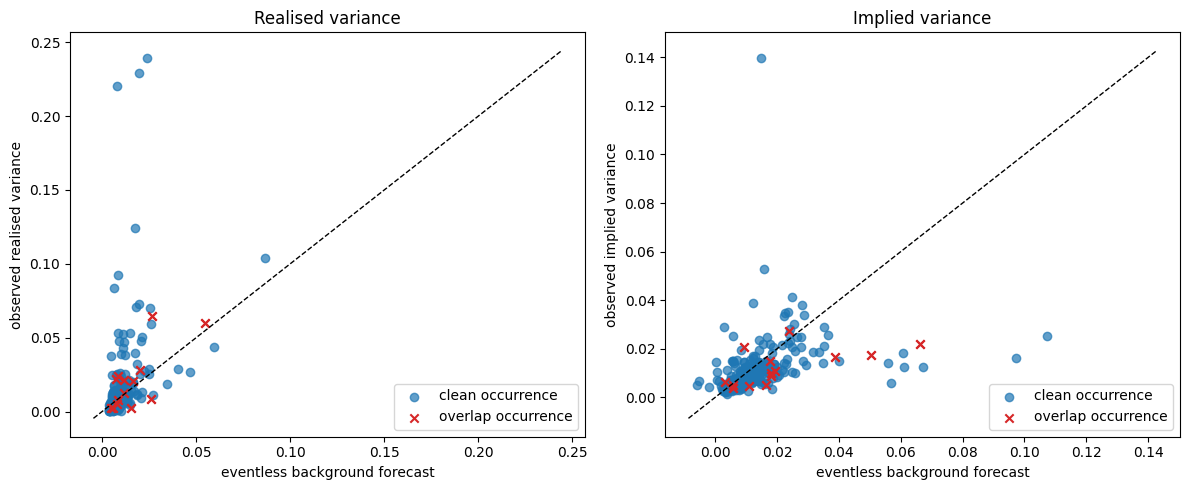

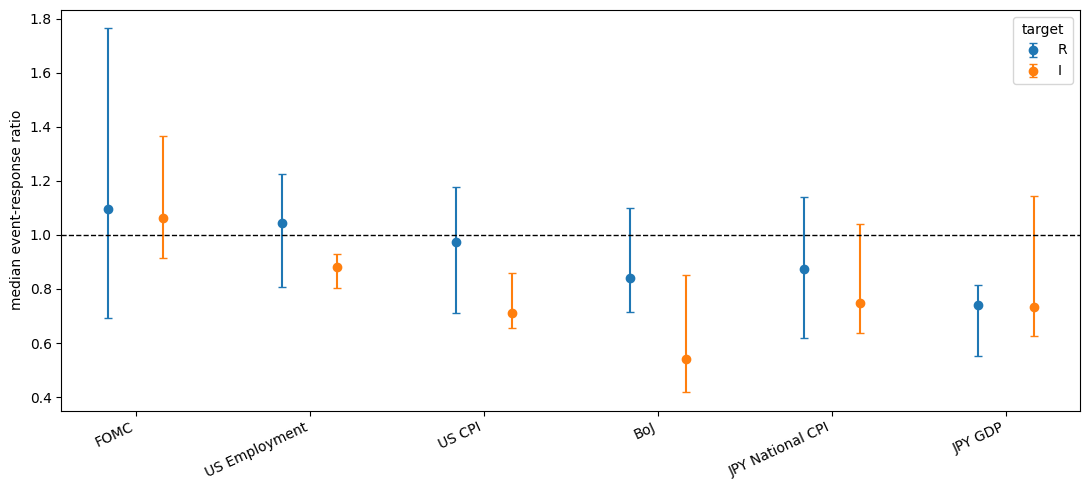

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for axis, target, label in zip(axes, ['R', 'I'], ['Realised variance', 'Implied variance']):
    plot_data = event_weights.loc[event_weights['sample_split'].eq('test') & event_weights['target'].eq(target) & event_weights['equation_eligible']].copy()
    clean = plot_data.loc[plot_data['is_clean_single_family']]
    overlap = plot_data.loc[plot_data['is_overlap']]
    axis.scatter(clean['raw_background_forecast'], clean['actual'], alpha=0.7, label='clean occurrence')
    axis.scatter(overlap['raw_background_forecast'], overlap['actual'], marker='x', color='tab:red', label='overlap occurrence')
    plot_min = min(plot_data['raw_background_forecast'].min(), plot_data['actual'].min())
    plot_max = max(plot_data['raw_background_forecast'].max(), plot_data['actual'].max())
    margin = 0.02 * (plot_max - plot_min) if plot_max > plot_min else 0.01
    axis.plot([plot_min - margin, plot_max + margin], [plot_min - margin, plot_max + margin], 'k--', linewidth=1)
    axis.set(xlabel='eventless background forecast', ylabel=f'observed {label.lower()}', title=label)
    axis.legend()
fig.tight_layout()
fig.savefig(FIGURES / '18_figure_18_1_event_variance_vs_background.png', dpi=160)
plt.show()

fig, axis = plt.subplots(figsize=(11, 5))
families = list(FAMILY_LABELS)
for offset, target, color in [(-0.16, 'R', 'tab:blue'), (0.16, 'I', 'tab:orange')]:
    values = table_18_6.loc[table_18_6['target'].eq(target)].set_index('family').reindex(families)
    median = values['median'].to_numpy(float)
    errors = np.vstack([median - values['bootstrap_ci_lower'].to_numpy(float), values['bootstrap_ci_upper'].to_numpy(float) - median])
    axis.errorbar(np.arange(len(families)) + offset, median, yerr=errors, fmt='o', capsize=3, color=color, label=target)
axis.axhline(1, color='black', linestyle='--', linewidth=1)
axis.set_xticks(np.arange(len(families)), families, rotation=25, ha='right')
axis.set_ylabel('median event-response ratio')
axis.legend(title='target')
fig.tight_layout()
fig.savefig(FIGURES / '18_figure_18_2_pooled_event_response_ratios.png', dpi=160)
plt.show()

## 15. Exports and integrity assertions

All statuses are derived from executed checks. Pipeline completion does not require every raw event background to be positive; non-positive forecasts remain a visible empirical limitation.

In [19]:
all_coefficients = pd.concat([train_coefficients, final_coefficients], ignore_index=True)
calibration_summary = pd.concat([pd.DataFrame([residual_scale_row(m) for m in [*train_models.values(), *final_models.values()]]), table_18_2.assign(record_type='calibration_support')], ignore_index=True, sort=False)
pooled_event_weights = pd.concat([table_18_6, table_18_s1], ignore_index=True)
exports = {'18_event_family_mapping.csv': event_family_mapping, '18_event_mapping_audit.csv': mapping_audit, '18_event_occurrences.csv': occurrences, '18_event_day_flags.csv': event_day_flags, '18_eventless_coefficients.csv': all_coefficients, '18_eventless_calibration_summary.csv': calibration_summary, '18_eventless_forecasts.csv': forecasts, '18_validation_background_comparison.csv': table_18_3, '18_positivity_audit.csv': table_18_5, '18_event_response_weights.csv': event_weights, '18_pooled_event_weights.csv': pooled_event_weights}
for filename, frame in exports.items():
    frame.to_csv(PROCESSED / filename, index=False)
    assert len(pd.read_csv(PROCESSED / filename)) == len(frame)
print('Core Notebook 18 outputs written; final integrity/status record follows.')

Core Notebook 18 outputs written; final integrity/status record follows.


## 16. Final derived integrity status

Methodological and integrity checks determine pipeline completion. Empirical status fields describe the realised output and do not invalidate a complete frozen-methodology pipeline.

In [20]:
def normalize_contract_value(raw_value, expected_value):
    if isinstance(expected_value, bool):
        return parse_bool(raw_value)
    if isinstance(expected_value, int):
        return int(raw_value)
    return str(raw_value)

notebook16_contract_loaded = all(
    normalize_contract_value(spec16[key], expected) == expected
    for key, expected in expected_contract.items()
)

r_overlap_base = panel['is_overlap'] & panel['R_base_eligible']
i_overlap_base = panel['is_overlap'] & panel['I_base_eligible']
r_overlap_masked = (~panel.loc[r_overlap_base, 'R_eventless_eligible']).all()
i_overlap_masked = (~panel.loc[i_overlap_base, 'I_eventless_eligible']).all()
overlaps_masked_once_in_background = bool(r_overlap_masked and i_overlap_masked)

raw_background_final = forecasts[['model_day', 'sample_split', 'forecast_stage', 'target', 'raw_background_forecast']].copy()
raw_background_final = raw_background_final.sort_values(['model_day', 'target']).reset_index(drop=True)
raw_background_reference = raw_background_original.sort_values(['model_day', 'target']).reset_index(drop=True)
raw_backgrounds_preserved = bool(
    raw_background_final[['model_day', 'sample_split', 'forecast_stage', 'target']].equals(raw_background_reference[['model_day', 'sample_split', 'forecast_stage', 'target']])
    and np.allclose(raw_background_final['raw_background_forecast'], raw_background_reference['raw_background_forecast'], equal_nan=True)
)
no_forecast_clipping = raw_backgrounds_preserved

def bootstrap_interval(values, seed=18, repetitions=10000):
    values = np.asarray(values, dtype=float)
    if len(values) < 2:
        return (np.nan, np.nan)
    rng = np.random.default_rng(seed)
    medians = np.median(rng.choice(values, size=(repetitions, len(values)), replace=True), axis=1)
    return tuple(np.quantile(medians, [0.025, 0.975]))

representative_pool = event_weights.loc[
    event_weights['sample_split'].eq('test') & event_weights['is_clean_single_family'] & event_weights['weight_defined'],
    ['family', 'target', 'response_ratio']
].sort_values(['family', 'target'])
representative_values = next(iter(representative_pool.groupby(['family', 'target'])))[1]['response_ratio'].to_numpy(dtype=float)
bootstrap_reproducible = bool(bootstrap_interval(representative_values) == bootstrap_interval(representative_values))

statuses = {
    'notebook16_contract_loaded': notebook16_contract_loaded,
    'overlaps_masked_once_in_background': overlaps_masked_once_in_background,
    'raw_backgrounds_preserved': raw_backgrounds_preserved,
    'no_forecast_clipping': no_forecast_clipping,
    'bootstrap_reproducible': bootstrap_reproducible,
    'notebook17_exercise2_complete': parse_bool(spec17['exercise_2_complete']),
    'model_day_unique': model_day_unique,
    'model_day_monotonic': model_day_monotonic,
    'lags_constructed_before_event_mask': len(lag_columns) == 36,
    'lags_preserved_after_event_merge': lags_preserved_after_event_merge,
    'six_family_universe_frozen': set(FAMILY_LABELS) == set(occurrences['family']),
    'component_rows_collapsed': not occurrences.duplicated(['family', 'model_day']).any(),
    'explicit_session_membership_used': bool(mapping_audit.loc[mapping_audit['mapping_status'].eq('MAPPED'), 'explicit_member'].all()),
    'all_modelled_event_occurrences_have_valid_mapping': all_modelled_event_occurrences_have_valid_mapping,
    'train_eventless_fit_complete': all(len(model['sample']) > 0 for model in train_models.values()),
    'validation_check_complete': len(table_18_3) == 4,
    'exercise3_design_frozen_before_test_event_response_analysis': DESIGN_FROZEN,
    'train_validation_eventless_fit_complete': len(final_models['R']['sample']) == 3240 and len(final_models['I']['sample']) == 2547,
    'test_event_responses_not_used_for_exercise3_design': bool(design_freeze['test_event_responses_not_used_for_exercise3_design']),
    'final_coefficients_fixed_through_test': test_backgrounds['forecast_stage'].eq('test_oos_background').all(),
    'strict_positive_denominator_rule': bool((event_weights['weight_defined'] == (event_weights['equation_eligible'] & event_weights['raw_background_forecast'].gt(0))).all()),
    'nonpositive_weights_are_undefined': bool(event_weights.loc[event_weights['equation_eligible'] & ~event_weights['background_positive'], 'response_ratio'].isna().all()),
    'event_weights_constructed': len(event_weights) == 2 * len(occurrences),
    'overlaps_retained_in_raw_event_export': bool(event_weights['is_overlap'].any()),
    'primary_pool_clean_only': bool((event_weights.loc[event_weights['sample_split'].eq('test') & event_weights['is_clean_single_family']].groupby(['family', 'target']).size() == table_18_6.set_index(['family', 'target'])['n_event_occurrences']).all()),
    'overlap_sensitivity_complete': len(table_18_s1) == 12,
    'positivity_audit_complete': len(table_18_5) == 54,
    'primary_pooling_complete': len(table_18_6) == 12,
    'all_event_backgrounds_positive': bool(forecasts.loc[forecasts['is_target_event_day'], 'background_positive'].all()),
    'all_six_families_have_estimable_primary_R_pool': bool(table_18_6.loc[table_18_6['target'].eq('R'), 'n_valid_positive_denominator'].ge(2).all()),
    'all_six_families_have_estimable_primary_I_pool': bool(table_18_6.loc[table_18_6['target'].eq('I'), 'n_valid_positive_denominator'].ge(2).all()),
}
integrity_status_names = [
    'notebook16_contract_loaded', 'notebook17_exercise2_complete',
    'model_day_unique', 'model_day_monotonic', 'lags_constructed_before_event_mask', 'lags_preserved_after_event_merge',
    'six_family_universe_frozen', 'component_rows_collapsed', 'explicit_session_membership_used', 'all_modelled_event_occurrences_have_valid_mapping',
    'train_eventless_fit_complete', 'validation_check_complete', 'exercise3_design_frozen_before_test_event_response_analysis', 'train_validation_eventless_fit_complete',
    'test_event_responses_not_used_for_exercise3_design', 'final_coefficients_fixed_through_test',
    'raw_backgrounds_preserved', 'no_forecast_clipping', 'strict_positive_denominator_rule', 'nonpositive_weights_are_undefined', 'event_weights_constructed',
    'overlaps_masked_once_in_background', 'overlaps_retained_in_raw_event_export', 'primary_pool_clean_only', 'overlap_sensitivity_complete',
    'positivity_audit_complete', 'primary_pooling_complete', 'bootstrap_reproducible'
]
statuses['exercise_3_pipeline_complete'] = all(statuses[name] for name in integrity_status_names)
statuses['exercise_3_primary_results_complete'] = bool(statuses['exercise_3_pipeline_complete'] and statuses['all_six_families_have_estimable_primary_R_pool'] and statuses['all_six_families_have_estimable_primary_I_pool'])

primary_specification = pd.DataFrame([{**design_freeze, **statuses, 'RUN_ID': RUN_ID, 'iv_specification': spec16['iv_specification'], 'iv_column': IV_COLUMN, 'final_R_eventless_N': len(final_models['R']['sample']), 'final_I_eventless_N': len(final_models['I']['sample'])}])
primary_specification.to_csv(PROCESSED / '18_primary_specification.csv', index=False)
assert len(pd.read_csv(PROCESSED / '18_primary_specification.csv')) == 1

methodological_statuses = pd.Series({name: statuses[name] for name in integrity_status_names + ['exercise_3_pipeline_complete']})
empirical_statuses = pd.Series({name: statuses[name] for name in ['all_event_backgrounds_positive', 'all_six_families_have_estimable_primary_R_pool', 'all_six_families_have_estimable_primary_I_pool', 'exercise_3_primary_results_complete']})
print('Methodological / integrity statuses')
display(methodological_statuses.rename('passed').to_frame())
print('Empirical result statuses')
display(empirical_statuses.rename('status').to_frame())
assert statuses['exercise_3_pipeline_complete']


Methodological / integrity statuses


,passed
notebook16_contract_loaded,True
notebook17_exercise2_complete,True
model_day_unique,True
model_day_monotonic,True
lags_constructed_before_event_mask,True
lags_preserved_after_event_merge,True
six_family_universe_frozen,True
component_rows_collapsed,True
explicit_session_membership_used,True
all_modelled_event_occurrences_have_valid_mapping,True


Empirical result statuses


,status
all_event_backgrounds_positive,False
all_six_families_have_estimable_primary_R_pool,True
all_six_families_have_estimable_primary_I_pool,True
exercise_3_primary_results_complete,True


## Exercise 3 summary

The frozen eventless recalibration is a maintained **conditional background**, not an identified causal model. The following compact handoff reports the executed validation, positivity, and pooled-ratio results without changing the Exercise 3 design.

In [21]:
validation_summary = table_18_3.pivot(index='target', columns='background_type', values='RMSE')
test_event_positivity = table_18_5.loc[(table_18_5['sample_split'].eq('test')) & (table_18_5['group_type'].eq('STATUS')) & (table_18_5['group_value'].eq('ANY_TARGET_EVENT'))].set_index('target')
print(
    'Exercise 3 retains close ordinary realised-variance validation behaviour after eventless recalibration, while ordinary implied-variance validation is less stable; the resulting fixed background remains the maintained conditional counterfactual for the response-ratio construction. '
    f"All realised TEST event backgrounds are positive ({int(test_event_positivity.loc['R', 'n_positive'])}/{int(test_event_positivity.loc['R', 'n_forecasts'])}); implied TEST event backgrounds are positive for {int(test_event_positivity.loc['I', 'n_positive'])}/{int(test_event_positivity.loc['I', 'n_forecasts'])} eligible event dates. All six families retain estimable clean TEST pools for both targets."
)
print(
    'Pooled ratios show heterogeneous event-associated deviations from the maintained conditional background: several implied-variance medians are below one, whereas FOMC is closer to or above one in both realised and implied variance. These are not identified causal treatment effects, and sub-one implied ratios do not establish uncertainty resolution given the unresolved Bloomberg daily-IV snapshot timing. The overlap-inclusive estimates remain a labelled, non-uniquely attributable sensitivity.'
)


Exercise 3 retains close ordinary realised-variance validation behaviour after eventless recalibration, while ordinary implied-variance validation is less stable; the resulting fixed background remains the maintained conditional counterfactual for the response-ratio construction. All realised TEST event backgrounds are positive (260/260); implied TEST event backgrounds are positive for 234/237 eligible event dates. All six families retain estimable clean TEST pools for both targets.
Pooled ratios show heterogeneous event-associated deviations from the maintained conditional background: several implied-variance medians are below one, whereas FOMC is closer to or above one in both realised and implied variance. These are not identified causal treatment effects, and sub-one implied ratios do not establish uncertainty resolution given the unresolved Bloomberg daily-IV snapshot timing. The overlap-inclusive estimates remain a labelled, non-uniquely attributable sensitivity.
